# Machine Learning in Computational Biology
## Spring 2026 • Assignment #2
### Heart Disease Classification using Repeated Nested Cross-Validation

Maria-Despoina Liassa


- The dataset UCI Heart Disease Dataset (Cleveland subset), contains 242 patient records and 14 attributes 
    - 13 features & 1 target variable
- The task is **binary classification**: predict whether a patient has heart disease based on the target variable
num
 - num = 0 --> no heart disease  
 - num = 1 --> presence of heart disease 
 All provided samples will be used in building the predictive models

## Task 1 : Data Loading, EDA and Preprocessing

We will:

- Inspect the dataset structure
- Explore data distributions
- Visualize categorical & numerical variables
- Detect missing values & outliers


In [26]:
# Load Libraries
import pandas as pd
import numpy as np
import sklearn
import matplotlib.pyplot as plt
import seaborn as sns


In [27]:
# Load data 
file_path = '../data/heart.csv'
df = pd.read_csv(file_path)

print("Total number of samples:")
print(len(df))

# View the dataframe 
df.head() 

# Class distribution 
print("\nClass distribution (Target Variable):")
print(df['num'].value_counts()) 


Total number of samples:
242

Class distribution (Target Variable):
num
0    131
1    111
Name: count, dtype: int64


Shape and Data Types


In [28]:
print("Shape:", df.shape)  # rows & columns (dataset size)
print("\nData Types:\n", df.dtypes)  # Data types of each feature

Shape: (242, 14)

Data Types:
 age         float64
sex         float64
cp          float64
trestbps    float64
chol        float64
fbs         float64
restecg     float64
thalach     float64
exang       float64
oldpeak     float64
slope       float64
ca          float64
thal        float64
num           int64
dtype: object


Basic Info

In [29]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 242 entries, 0 to 241
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       242 non-null    float64
 1   sex       242 non-null    float64
 2   cp        242 non-null    float64
 3   trestbps  242 non-null    float64
 4   chol      242 non-null    float64
 5   fbs       242 non-null    float64
 6   restecg   242 non-null    float64
 7   thalach   242 non-null    float64
 8   exang     242 non-null    float64
 9   oldpeak   242 non-null    float64
 10  slope     242 non-null    float64
 11  ca        241 non-null    float64
 12  thal      241 non-null    float64
 13  num       242 non-null    int64  
dtypes: float64(13), int64(1)
memory usage: 26.6 KB


Statistical summaries of numerical and categorical variables

In [30]:
 #Show summary statistics for all columns, including categorical ones
df.describe(include='all')

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num
count,242.000000,242.000000,242.000000,242.000000,242.000000,242.000000,242.000000,242.000000,242.000000,242.000000,242.000000,241.000000,241.000000,242.000000
mean,54.549587,0.681818,3.152893,130.958678,249.838843,0.144628,0.979339,149.962810,0.326446,0.999174,1.586777,0.609959,4.713693,0.458678
std,8.996981,0.466736,0.975516,17.622551,52.846867,0.352454,0.999786,22.686449,0.469885,1.122940,0.613397,0.883497,1.948552,0.499322
min,29.000000,0.000000,1.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,1.000000,0.000000,3.000000,0.000000
25%,48.000000,0.000000,2.250000,120.000000,212.000000,0.000000,0.000000,134.500000,0.000000,0.000000,1.000000,0.000000,3.000000,0.000000
50%,56.000000,1.000000,3.000000,130.000000,244.500000,0.000000,0.000000,153.500000,0.000000,0.800000,2.000000,0.000000,3.000000,0.000000
75%,61.000000,1.000000,4.000000,140.000000,277.750000,0.000000,2.000000,166.000000,1.000000,1.600000,2.000000,1.000000,7.000000,1.000000
max,77.000000,1.000000,4.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,3.000000,3.000000,7.000000,1.000000


Missing values

In [31]:
# We check for missong values and visualise them

df.isnull().sum()  # Check for missing values in each column

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          1
thal        1
num         0
dtype: int64

In [32]:
# Locate the samples with missing values in 'ca' and 'thal'
missing_samples = df[df['ca'].isnull() | df['thal'].isnull()]
print(missing_samples)

      age  sex   cp  trestbps   chol  fbs  restecg  thalach  exang  oldpeak  \
160  52.0  1.0  4.0     128.0  204.0  1.0      0.0    156.0    1.0      1.0   
209  43.0  1.0  4.0     132.0  247.0  1.0      2.0    143.0    1.0      0.1   

     slope   ca  thal  num  
160    2.0  0.0   NaN    1  
209    2.0  NaN   7.0    1  


<Axes: >

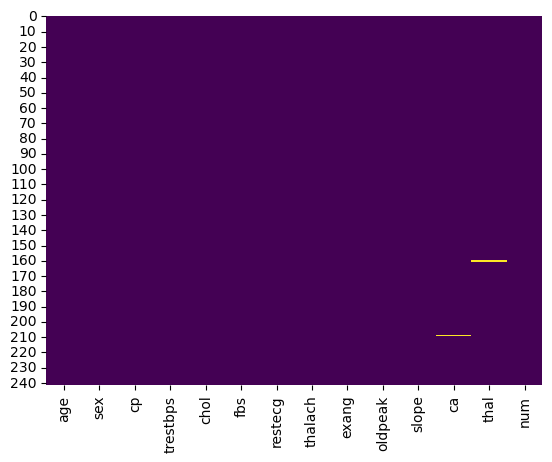

In [33]:
sns.heatmap(df.isnull(), cbar=False, cmap='viridis')  ## # Heatmap shows whether missingness is random or patterned  Visualize missing values

- From the Heatmap above, we observe that we have 2 missing values (one in 'ca' and another in 'thal' column)
- We don't observe any patterns, meaning the 2 missing values is a random incident 
- We can either delete or impute those missing values. This will be decided based on 
    1. the total number of missing values (**2 missing values**)
    2. if the values are missing from the target variable (class) (**No**)
    3. whether the class is imbalanced

Class imbalance check


/tmp/ipykernel_1899/1454778155.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='num', data=df, palette="viridis")


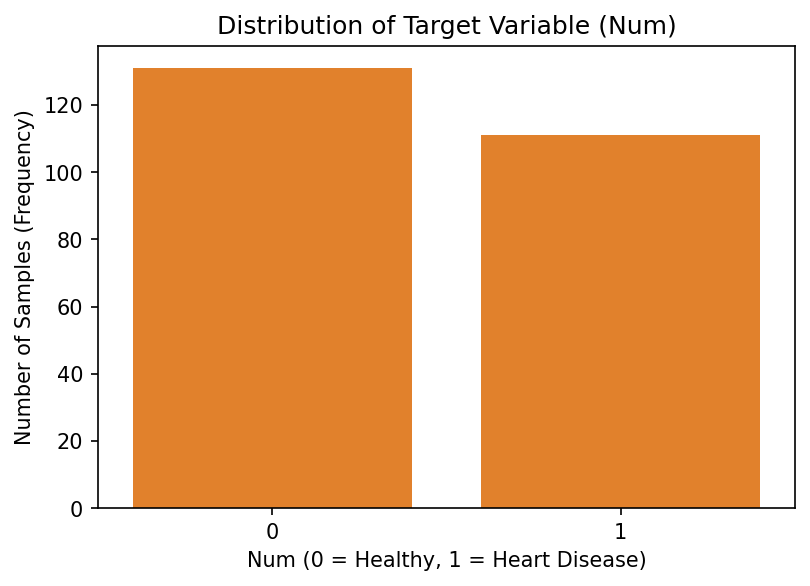

num
0    54.132231
1    45.867769
Name: proportion, dtype: float64

In [34]:
# 150 dpi quality
plt.figure(figsize=(6, 4), dpi=150) 
sns.countplot(x='num', data=df, palette="viridis") 

sns.countplot(x='num', data=df)  # Count of target variable classes

# Title & labels
plt.title('Distribution of Target Variable (Num)', fontsize=12)
plt.xlabel("Num (0 = Healthy, 1 = Heart Disease)", fontsize=10)
plt.ylabel("Number of Samples (Frequency)", fontsize=10)

# Save image in figures
plot_path = '../figures/Class Imbalance.png'
plt.savefig(plot_path, dpi=150, bbox_inches='tight')
plt.show()

# Percentages 
df['num'].value_counts(normalize=True) * 100  # Percentages of target variable classes

#print(f"Follow this path to locate the figure: {plot_path}")

- The target variable is not imbalanced
- **Given 1,2 and 3, is considered safe to delete the 2 samples with the missing values**
- Otherwise, we could impute  
    - the continuous variable 'thal' with the median (so it wouldn't be affected by outliers, if any)
    - the ordinal variable 'ca' with the most frequent value 

In [35]:
# 1. Delete samples with missing values in columns 'ca' and 'thal'
df.dropna(subset=['ca', 'thal'], inplace=True)

# 2. Index reset, to keep the index consistent after dropping rows
df.reset_index(drop=True, inplace=True)

# After handling missing values, we check the dataset again to confirm the changes:

# 1. Check for the new size of the dataset 
print(f"New size of dataset: {df.shape}")

# 2. Confirmation of no missing values 
print("\nMissing values per column:")
print(df.isnull().sum())

# 3. Check if the class imbalance remains correct
print("\nNew class distribution (Target Variable):")
print(df['num'].value_counts()) 

New size of dataset: (240, 14)

Missing values per column:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
num         0
dtype: int64

New class distribution (Target Variable):
num
0    131
1    109
Name: count, dtype: int64


explore data distributions


